In [ ]:
pip install pandas numpy scikit-learn

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [ ]:
heart_data=pd.read_csv('/content/Heartdisease.csv')

In [ ]:
heart_data.head()
heart_data.describe()
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [ ]:
print(heart_data.shape)

(303, 14)


In [ ]:
print(heart_data.groupby('target').size())

target
0    138
1    165
dtype: int64


In [ ]:
from matplotlib import pyplot
from pandas.plotting import scatter_matrix

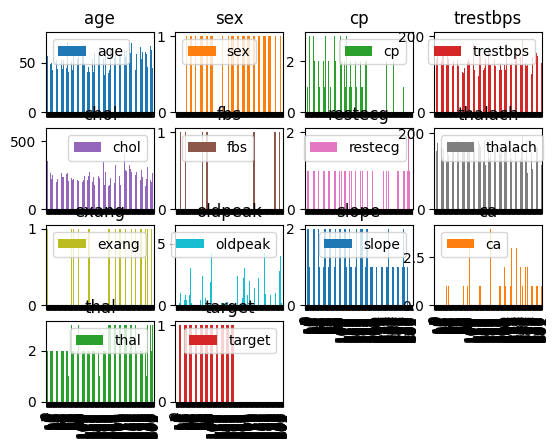

In [ ]:
heart_data.plot(kind='bar',subplots=True,layout=(4,4))
pyplot.title('BAR PLOT')
pyplot.show()

In [ ]:
X = heart_data.drop('target', axis=1)
y = heart_data['target']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
print("\nLOGISTIC REGRESSION")

lr_model = LogisticRegression(max_iter=1000)



LOGISTIC REGRESSION


In [ ]:
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy * 100)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))


Accuracy: 85.24590163934425

Confusion Matrix
[[25  4]
 [ 5 27]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [ ]:
print("\nSVM MODEL")

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Accuracy:", svm_accuracy * 100)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, svm_pred))

print("\nClassification Report")
print(classification_report(y_test, svm_pred))



SVM MODEL
Accuracy: 86.88524590163934

Confusion Matrix
[[26  3]
 [ 5 27]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [ ]:
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", rf_accuracy * 100)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))


Accuracy: 83.60655737704919

Confusion Matrix
[[24  5]
 [ 5 27]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [ ]:
print("\nMODEL COMPARISON")

print("Logistic Regression Accuracy :", lr_accuracy * 100)
print("SVM Accuracy                 :", svm_accuracy * 100)
print("Random Forest Accuracy       :", rf_accuracy * 100)


MODEL COMPARISON
Logistic Regression Accuracy : 85.24590163934425
SVM Accuracy                 : 86.88524590163934
Random Forest Accuracy       : 83.60655737704919


In [ ]:
sample_patient = X_test[0].reshape(1, -1)

prediction = rf_model.predict(sample_patient)

if prediction[0] == 1:
    print("\nPrediction: No Disease")
else:
    print("\nPrediction: Disease Detected")


Prediction: Disease Detected
